In [1]:
import sys
sys.path.append('../')

In [2]:
import numpy as np
from game.Users import Users
from game.Producers import *
from sklearn.preprocessing import normalize
from game.plotting import *
from game.Embeddings import *
from tqdm import tqdm
import pandas as pd
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'font.size' : 15,                   # Set font size to 11pt
    'axes.labelsize': 15,               # -> axis labels
    'xtick.labelsize':12,
    'ytick.labelsize':12,
    'legend.fontsize': 12,
    'lines.linewidth':2,
    'text.usetex': False,
    'pgf.rcfonts': False,
})

In [3]:
df_100 = pd.read_pickle("../saved_frames/movielens-100k_new_softmax_temp_100.0/concseeds5.pkl")
df_10 = pd.read_pickle("../saved_frames/movielens-100k_new_softmax_temp_10.0/concseeds5.pkl")
df_1 = pd.read_pickle("../saved_frames/movielens-100k_new_softmax_temp_1.0/concseeds5.pkl")
df_01 = pd.read_pickle("../saved_frames/movielens-100k_new_softmax_temp_0.1/concseeds5.pkl")
df_001 = pd.read_pickle("../saved_frames/movielens-100k_new_softmax_temp_0.01/concseeds5.pkl")
df_linear = pd.read_pickle("../saved_frames/movielens-100k_new_linear_temp_1.0/concseeds5.pkl")
df_rand = pd.read_pickle("../saved_frames/movielens-100k_new_random_temp_1.0/concseeds5.pkl")

(df_001['NE_exists'] == False).sum(), (df_01['NE_exists'] == False).sum(), \
(df_1['NE_exists']==False).sum(), (df_10['NE_exists']==False).sum(), \
(df_100['NE_exists']==False).sum(), (df_linear['NE_exists']==False).sum(), (df_rand['NE_exists']==False).sum()

(18, 0, 0, 0, 0, 3, 0)

In [4]:
df_001[df_001['NE_exists']==False]

,dimension,emb_seed,nprod,NE_exists,iters,last_profile_compact,producer_dist,user_dist,total_prod_util,avg_prod_util,max_prod_util,min_prod_util,total_user_util,avg_user_util,max_user_util,min_user_util
24,15,13,2,False,499,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, ...","[0.06883625645399127, 0.0648861598966524, 0.06...",84.253470,42.126735,42.257752,41.995719,84.253470,0.089346,0.290794,0.001013
51,50,13,20,False,499,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[0.0, 0.05, 0.0, 0.05, 0.0, 0.0, 0.05, 0.0, 0....","[0.020046522574497554, 0.020375534845551806, 0...",40.577413,2.028871,2.419112,1.886173,40.577413,0.043030,0.151757,0.020544
52,50,13,30,False,499,"[1.0, 1.0, 0.0, 2.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[0.03333333333333333, 0.03333333333333333, 0.0...","[0.020046522574497554, 0.020375534845551806, 0...",42.204481,1.406816,1.610180,1.286915,42.204481,0.044756,0.158074,0.022195
25,15,29,5,False,499,"[1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.2, 0.2, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, ...","[0.06766925960318655, 0.06847490301121467, 0.0...",109.571645,21.914329,24.720075,20.408895,109.571645,0.116195,0.356890,0.022375
53,50,29,40,False,499,"[2.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 3.0, ...","[0.05, 0.025, 0.0, 0.0, 0.025, 0.025, 0.0, 0.0...","[0.020251869677749983, 0.02037633754647605, 0....",43.240005,1.081000,1.272583,0.984105,43.240005,0.045854,0.194702,0.020618
12,10,17,2,False,499,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0, ...","[0.09743714394223246, 0.09873632701790554, 0.1...",124.830951,62.415475,62.665339,62.165612,124.830951,0.132376,0.502338,0.001905
36,20,17,2,False,499,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, ...","[0.050741754962531076, 0.05154969872898003, 0....",63.934697,31.967348,32.291553,31.643144,63.934697,0.067799,0.249497,0.000626
49,50,17,5,False,499,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.02112052385273129, 0.019475971874696935, 0....",33.756759,6.751352,7.244627,6.481669,33.756759,0.035797,0.153991,0.005438
50,50,17,10,False,499,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.02112052385273129, 0.019475971874696935, 0....",37.291223,3.729122,4.335581,3.362099,37.291223,0.039545,0.153929,0.012222
59,50,17,100,False,499,"[3.0, 1.0, 0.0, 0.0, 2.0, 2.0, 2.0, 3.0, 3.0, ...","[0.03, 0.01, 0.0, 0.0, 0.02, 0.02, 0.02, 0.03,...","[0.02112052385273129, 0.019475971874696935, 0....",42.878932,0.428789,0.488640,0.408304,42.878932,0.045471,0.153966,0.022891


In [64]:
# dim, emb_seed, nprod = 15, 13, 2
# dim, emb_seed, nprod = 15, 29, 5
# dim, emb_seed, nprod = 10, 23, 2
# dim, emb_seed, nprod = 100, 23, 50 # good vals, plateaus after round 20, total utility constant


# dim, emb_seed, nprod = 100, 17, 20 # good

dim, emb_seed, nprod = 50, 17, 10

temp_greedy = 0.01
emb_obj = Movielens_100k_Embedding()
probability = Probability(prob_str = 'softmax', temp=temp_greedy, topk=100)

In [65]:
nue = emb_obj.get_nue(seed = emb_seed, dimension = dim)
PEng = ProducersEngagementGame(num_producers = nprod, users = Users(nue), 
                               probability = probability) # add probability object

In [66]:
converged, last_profile, last_profile_compact, iters, prod_utilarr =  PEng.best_response_dynamics(max_iter=500,
                                                                                                  verbose=True)

##### PRODUCERS FOR ITER 0
 tensor([0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
##### PRODUCERS FOR ITER 0 
 tensor([0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
##### PRODUCERS FOR ITER 1 
 tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
##### PRODUCERS FOR ITER 2 
 tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.

##### PRODUCERS FOR ITER 33 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 34 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 35 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 36 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0

##### PRODUCERS FOR ITER 66 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 67 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 68 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 69 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0

##### PRODUCERS FOR ITER 102 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 103 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 104 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 105 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1

##### PRODUCERS FOR ITER 137 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 138 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 139 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 140 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

...

##### PRODUCERS FOR ITER 346 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 347 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 348 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 349 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

##### PRODUCERS FOR ITER 380 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 381 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 382 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 383 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

##### PRODUCERS FOR ITER 416 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 417 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 418 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 419 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

##### PRODUCERS FOR ITER 449 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 450 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 451 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 452 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

##### PRODUCERS FOR ITER 484 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 0., 0., 0.])
##### PRODUCERS FOR ITER 485 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 486 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 0.])
##### PRODUCERS FOR ITER 487 
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 2., 0., 0., 0., 1

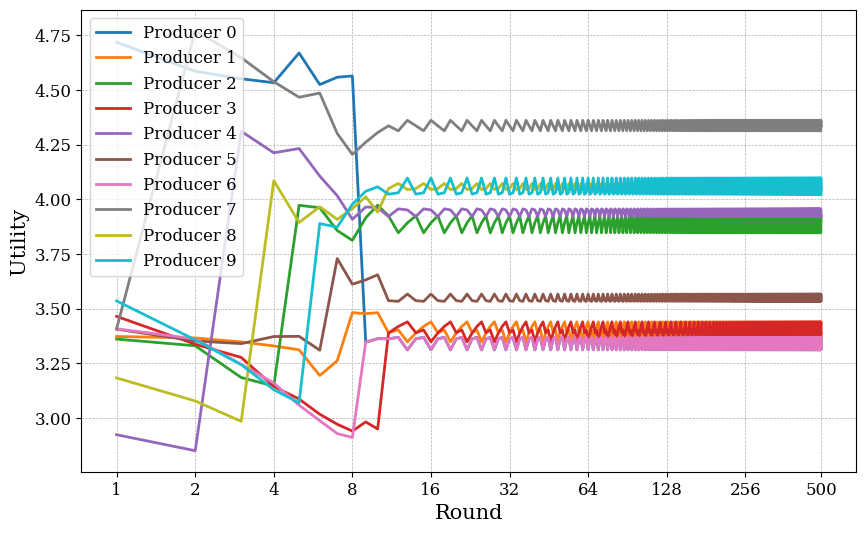

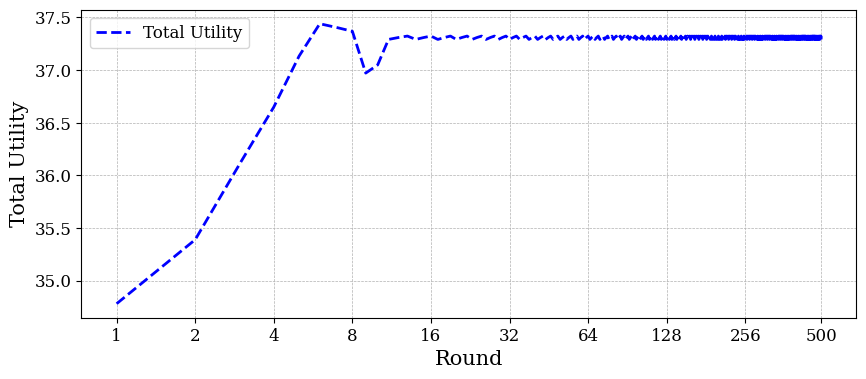

In [67]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_utilities(prod_utilarr, t_1=0, t_2=None, save_plots=True):
    """
    Plots utility curves for each producer in one plot and total utility in a separate plot,
    with the x-axis (rounds) in log base 2 scale. Saves plots as PDFs if save_plots=True.

    Parameters:
    - prod_utilarr: torch.Tensor of shape (num_rounds, num_producers)
    - t_1: start round index (inclusive)
    - t_2: end round index (exclusive), defaults to last round if None
    - save_plots: bool, if True, saves the plots as PDFs
    """
    # Convert tensor to numpy for plotting
    prod_utilarr_np = prod_utilarr.numpy()
    
    # Default t_2 to the last round if not provided
    if t_2 is None:
        t_2 = prod_utilarr_np.shape[0]

    # Correctly set rounds (no +1 shift) to start from t_1
    rounds = np.array(range(t_1 + 1, t_2 + 1))  # Rounds start from 1 correctly
    selected_utilities = prod_utilarr_np[t_1:t_2, :]
    total_utility = selected_utilities.sum(axis=1)

    # Define custom x-ticks: Include round 1 and min(2^10, last round)
    last_tick = min(2**10, rounds[-1])  # Ensure it doesn't exceed available data
    custom_ticks = [1] + list(2**np.arange(1, np.log2(last_tick).astype(int) + 1)) + [last_tick]
    custom_ticks = sorted(set(custom_ticks))  # Remove duplicates if any

    # Plot each producer's utility curve
    plt.figure(figsize=(10, 6))
    for j in range(selected_utilities.shape[1]):
        plt.plot(rounds, selected_utilities[:, j], label=f'Producer {j}')

    plt.xscale('log', base=2)  # Set x-axis to log base 2
    plt.xticks(custom_ticks, labels=[str(x) for x in custom_ticks])  # Explicit tick labels
    plt.xlabel('Round')
    plt.ylabel('Utility')
#     plt.title(f'Utility Curves for Each Producer (Rounds {t_1+1} to {t_2})')
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    if save_plots:
        plt.savefig("all_util_plot.pdf", format="pdf", bbox_inches="tight")  # Save as PDF

    plt.show()

    # Plot total utility separately
    plt.figure(figsize=(10, 4))
    plt.plot(rounds, total_utility, label='Total Utility', linewidth=2, linestyle='--', color='blue')

    plt.xscale('log', base=2)  # Set x-axis to log base 2
    plt.xticks(custom_ticks, labels=[str(x) for x in custom_ticks])  # Explicit tick labels
    plt.xlabel('Round')
    plt.ylabel('Total Utility')
#     plt.title(f'Total Utility Over Rounds {t_1+1} to {t_2}')
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    if save_plots:
        plt.savefig("tot_util_plot.pdf", format="pdf", bbox_inches="tight")  # Save as PDF

    plt.show()

# Example usage
plot_utilities(torch.stack(prod_utilarr), t_1=0)  # Plots and saves PDFs

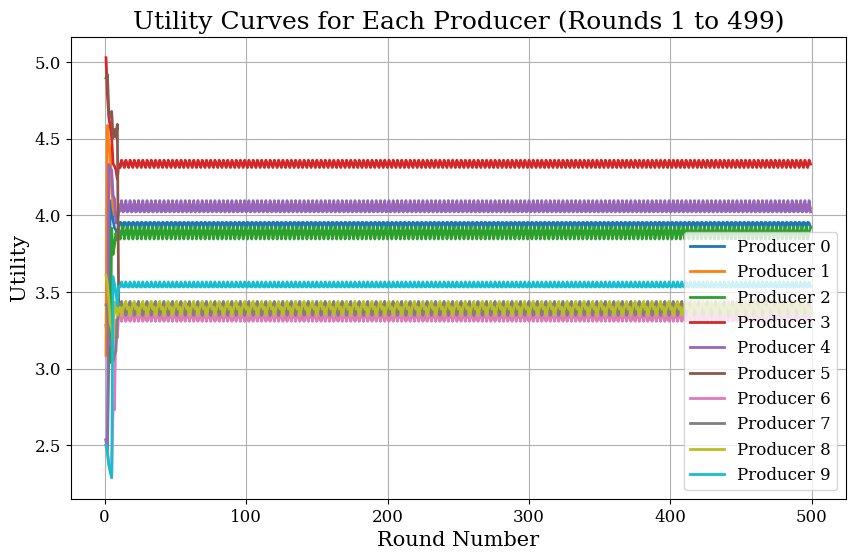

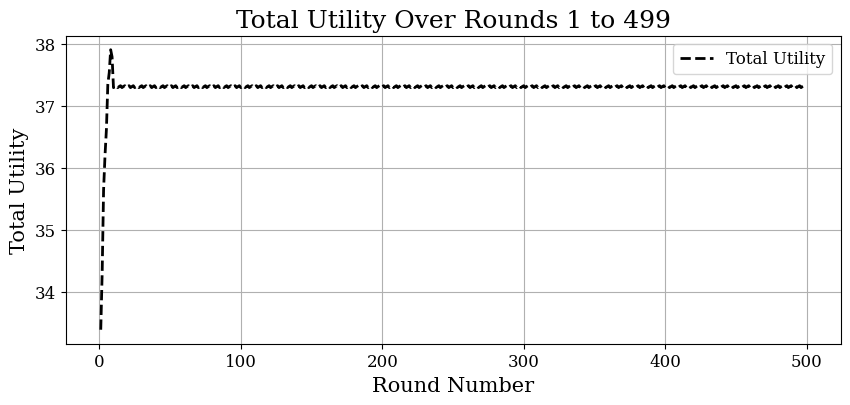

In [55]:
import torch
import matplotlib.pyplot as plt

def plot_utilities(prod_utilarr, t_1=0, t_2=None):
    """
    Plots utility curves for each producer in one plot and total utility in a separate plot over rounds [t_1, t_2].
    
    Parameters:
    - prod_utilarr: torch.Tensor of shape (num_rounds, num_producers)
    - t_1: start round index (inclusive)
    - t_2: end round index (exclusive), defaults to last round if None
    """
    # Convert tensor to numpy for plotting
    prod_utilarr_np = prod_utilarr.numpy()
    
    # Default t_2 to the last round if not provided
    if t_2 is None:
        t_2 = prod_utilarr_np.shape[0]

    # Slice the required rounds
    rounds = range(t_1, t_2)
    selected_utilities = prod_utilarr_np[t_1:t_2, :]
    total_utility = selected_utilities.sum(axis=1)

    # Plot each producer's utility curve
    plt.figure(figsize=(10, 6))
    for j in range(selected_utilities.shape[1]):
        plt.plot(rounds, selected_utilities[:, j], label=f'Producer {j}')

    plt.xlabel('Round Number')
    plt.ylabel('Utility')
    plt.title(f'Utility Curves for Each Producer (Rounds {t_1} to {t_2-1})')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot total utility separately
    plt.figure(figsize=(10, 4))
    plt.plot(rounds, total_utility, label='Total Utility', linewidth=2, linestyle='--', color='black')
    
    plt.xlabel('Round Number')
    plt.ylabel('Total Utility')
    plt.title(f'Total Utility Over Rounds {t_1} to {t_2-1}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_utilities(torch.stack(prod_utilarr), t_1=1)  # Adjust indices as needed

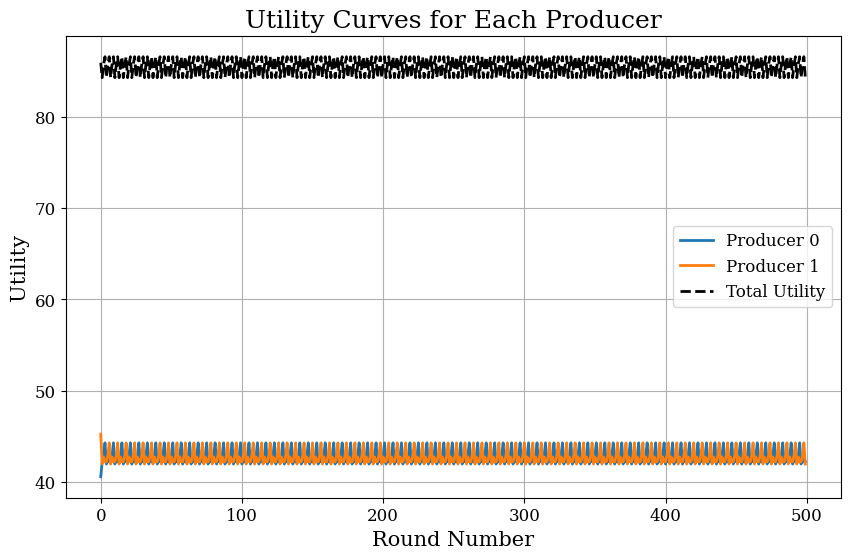

In [16]:
prod_utilarr = prod_utilarr.numpy()

# Compute total utility per round
total_utility = prod_utilarr.sum(axis=1)
num_producers =  prod_utilarr.shape[1]

# Plot each producer's utility curve
plt.figure(figsize=(10, 6))
for j in range(num_producers):
    plt.plot(prod_utilarr[:, j], label=f'Producer {j}')

# Plot total utility
plt.plot(total_utility, label='Total Utility', linewidth=2, linestyle='--', color='black')

plt.xlabel('Round Number')
plt.ylabel('Utility')
plt.title('Utility Curves for Each Producer')
plt.legend()
plt.grid(True)
plt.show()